# MA-UQNet: multi-modal uncertainty quantification for wheat biomass — synthetic example

**Paper:** *MA-UQNet: A multi-modal uncertainty quantification neural network for remote sensing-based wheat aboveground biomass estimation* — Artificial Intelligence in Agriculture 16(2):788–803 (June 2026), [DOI 10.1016/j.aiia.2026.03.007](https://doi.org/10.1016/j.aiia.2026.03.007).

**Author code:** `JinpC-tech/MA-UQNet` @ commit `ebfabdae2c770444788db857b393470bf333506f` (file `MA_UQNet_example.py`, run unmodified).

**Scope (partial demonstration):** this notebook trains the authors' self-contained example
end-to-end on its **embedded synthetic wheat-biomass data** (chronological 2018–2019 train /
2020–2021 test split) and reports **R², RMSE, 95 % interval coverage, and the epistemic vs
aleatoric uncertainty shares**, exactly as the authors' script computes them. The paper's
published real-data results (e.g. R² = 0.856 with 97.18 % coverage on a 1272-sample
2012–2022 field dataset) are **not** reproduced here: that dataset and the published
configuration are not publicly available.

**すべて日本語の概要:** このノートブックは著者公開の自己完結サンプル `MA_UQNet_example.py`
を**そのまま**実行し、内蔵の合成データ（2018–2019年訓練／2020–2021年試験の年代分割）で
MA-UQNet を訓練し、R²・RMSE・95%区間被覆率・認識論的/偶然的不確実性の内訳を取得します。
本論文の実データ結果（R²=0.856 等）の再現では**ありません**。

**Provenance note:** all scientific code (data generation, model, training, uncertainty
estimation, metrics) is imported from the authors' pinned file. The download/verification,
preview, and plotting cells are AI-generated glue written for this notebook.
**Provenance 注:** 科学的処理はすべて著者コード（固定コミット）からそのまま呼び出します。
ダウンロード検証・プレビュー・可視化のセルのみ本ノートブック用の補助コードです。

## Runtime selection & Run all — ランタイム選択と実行方法

**Recommended runtime: CPU** (Runtime → Change runtime type → CPU). The model is tiny
(hidden dim 32, fusion dim 64) and the authors' script auto-selects CUDA only when a GPU is
present, so a **T4 GPU runtime also runs the same notebook faithfully**. No heavy downloads:
only the ~27 KB author script is fetched; torch/numpy/pandas/scikit-learn/tqdm are
preinstalled in Colab.

**Expected duration:** ~5–25 min end-to-end on CPU (dominated by up to 300 training epochs
with early stopping; the exact time depends on when early stopping triggers).
**推奨ランタイムは CPU**（小規模モデルのため）。T4 GPU でも同一コードが動作します。
所要時間の目安は CPU で約 5–25 分（早期停止がいつ効くかで変動）。

Run all cells top to bottom (Runtime → Run all).

### 1. Environment check — 環境確認

Prints the Python/torch/numpy/pandas/scikit-learn versions and the device that the authors'
script will select (`cuda` when a GPU is allocated, otherwise `cpu`). Expect torch ≥ 1.9 per
the script header; Colab's preinstalled stack satisfies this. No installs are performed.
環境とデバイスを表示するだけです。依存パッケージは Colab 標準搭載品を使用し、インストールは行いません。

In [ ]:
import sys
import numpy as np
import torch
import pandas as pd
import sklearn

print("Python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("numpy:", np.__version__, "| pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Compute device the author script will select:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.13.16
torch: 2.11.0+cpu
numpy: 2.1.3 | pandas: 2.2.3 | scikit-learn: 1.6.1
Compute device the author script will select: cpu


### 2. Fetch the pinned author script — 著者スクリプトの取得（固定コミット）

Downloads `MA_UQNet_example.py` from the pinned commit `ebfabdae2c770444788db857b393470bf333506f` (raw.githubusercontent.com,
public, no token) and verifies **both** the byte count (26,922) and the **Git blob SHA-1**
`dec57606d0dd7a3fb2996e02d3651036210aeac2` computed from the downloaded bytes. Assertions
fail loudly on any mismatch, so an error page or altered file can never be executed silently.
固定コミットから生ファイルを取得し、バイト数と Git blob SHA-1 を検証します。不一致なら即座に停止します。

In [ ]:
import hashlib
import urllib.request

REPO_COMMIT = "ebfabdae2c770444788db857b393470bf333506f"
SCRIPT_URL = f"https://raw.githubusercontent.com/JinpC-tech/MA-UQNet/{REPO_COMMIT}/MA_UQNet_example.py"
EXPECTED_BLOB_SHA1 = "dec57606d0dd7a3fb2996e02d3651036210aeac2"
EXPECTED_SIZE = 26922  # bytes, from the GitHub contents API for this commit

script_path = "/content/MA_UQNet_example.py"
with urllib.request.urlopen(SCRIPT_URL, timeout=60) as r:
    src = r.read()
assert len(src) == EXPECTED_SIZE, f"unexpected size: {len(src)} bytes"
blob_sha1 = hashlib.sha1(b"blob %d\x00" % len(src) + src).hexdigest()
assert blob_sha1 == EXPECTED_BLOB_SHA1, f"git blob SHA-1 mismatch: {blob_sha1}"
with open(script_path, "wb") as f:
    f.write(src)
print(f"Downloaded {len(src)} bytes from pinned commit {REPO_COMMIT}")
print("Git blob SHA-1 verified:", blob_sha1)


Downloaded 26922 bytes from pinned commit ebfabdae2c770444788db857b393470bf333506f
Git blob SHA-1 verified: dec57606d0dd7a3fb2996e02d3651036210aeac2


### 3. Script identity check — スクリプト内容の確認

Prints the file header (which documents the example/synthetic-data intent and required
packages) and the scientific constants the run will use: seed 42, 5000 samples, 12 spectral
+ 5 environmental features, hidden dim 32, fusion dim 64, batch 32, ≤ 300 epochs, LR 1e-3,
30 Monte-Carlo samples, and selected Zadoks stages [3, 4, 6, 7]. Confirm these before
training; they are the authors' own defaults, unchanged.
ヘッダと定数を表示して確認します。これらは著者スクリプト既定値そのものです。

In [ ]:
text = src.decode("utf-8")
print("\n".join(text.splitlines()[:6]))
print("...")
for key in ["RANDOM_SEED", "N_SAMPLES", "N_SPECTRAL", "N_ENV", "SELECTED_STAGES",
            "HIDDEN_DIM", "FUSION_DIM", "DROPOUT_RATE", "BATCH_SIZE", "EPOCHS",
            "LR", "WEIGHT_DECAY", "PATIENCE", "NUM_MC_SAMPLES"]:
    line = next(l.strip() for l in text.splitlines() if l.startswith(key + " "))
    print(line)


# MA-UQNet: Multi-modal Attention Uncertainty Quantification Network
# Example implementation - Using synthetic data for demonstration
# 
# Required packages:
# torch>=1.9.0, numpy>=1.19.0, pandas>=1.1.0, scikit-learn>=0.24.0, tqdm>=4.50.0

...
RANDOM_SEED = 42
N_SAMPLES = 5000
N_SPECTRAL = 12
N_ENV = 5
SELECTED_STAGES = [3, 4, 6, 7]
HIDDEN_DIM = 32
FUSION_DIM = 64
DROPOUT_RATE = 0.3
BATCH_SIZE = 32
EPOCHS = 300
LR = 0.001
WEIGHT_DECAY = 1e-5
PATIENCE = 30
NUM_MC_SAMPLES = 30


### 4. Import the author module — 著者モジュールの読み込み

Imports the downloaded file as a module. Importing executes only the header/seed lines
(`RANDOM_SEED = 42; torch.manual_seed(42); np.random.seed(42)`) and definitions — the
`if __name__ == "__main__"` guard prevents `main()` from running at import. The model,
data generator, training loop, and MC-dropout evaluation used below are the authors' own
functions, unmodified.
ファイルをモジュールとして読み込みます。`__main__` ガードにより main() は実行されず、
以降のセルで著者の関数をそのまま呼び出します。

In [ ]:
import sys

sys.path.insert(0, "/content")
import MA_UQNet_example as mauqnet

print("Module imported. RANDOM_SEED =", mauqnet.RANDOM_SEED)
print("Selected Zadoks stages:", [mauqnet.GROWTH_STAGES[s] for s in mauqnet.SELECTED_STAGES])


Module imported. RANDOM_SEED = 42
Selected Zadoks stages: ['Stem elongation', 'Booting', 'Anthesis', 'Milk development']


### 5. Input preview — 合成データのプレビュー

There is no external dataset: the "input" is generated by the authors'
`generate_synthetic_data()` (5000 samples; stage-dependent spectral means + Gaussian noise,
environmental covariates, biomass = stage effect + spectral effect + environment effect +
noise, in kg/ha). This AI-added preview cell re-seeds numpy with the author seed and calls
that generator to show the per-stage biomass distributions and stage-mean spectral
signatures. **This graph is an added visualization of the authors' synthetic generator, not a
paper figure.** The training cell below re-seeds RNGs identically to a plain
`python MA_UQNet_example.py` run, so the preview does not alter training data.
外部データはなく、著者の `generate_synthetic_data()` が生成する合成データが入力です。
このプレビューは付加的な可視化であり、論文の図ではありません。訓練セルでは著者と同じ
シード再設定を行うため、プレビューが訓練データに影響しません。

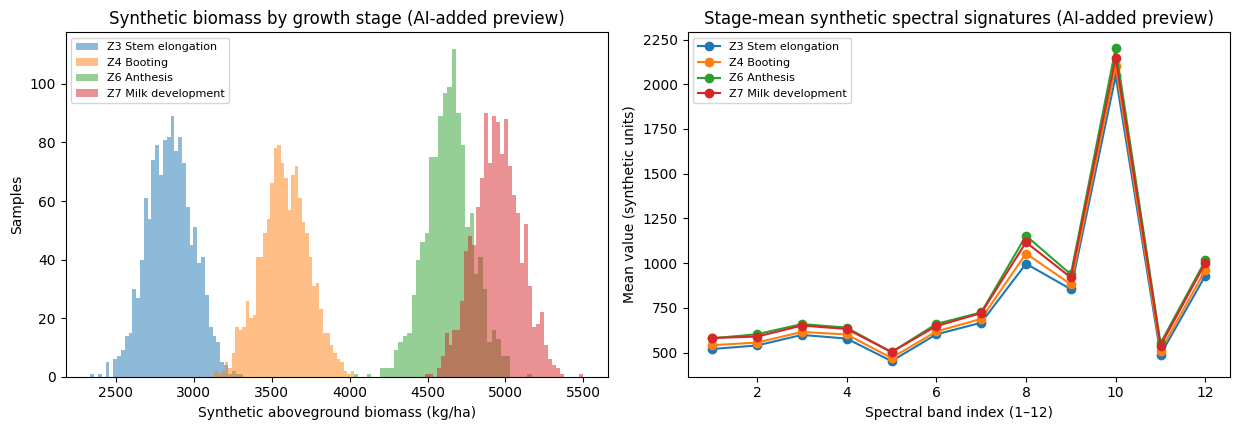

Samples per stage: Z3=1295, Z4=1240, Z6=1209, Z7=1256
Samples per year: 2018=1241, 2019=1246, 2020=1268, 2021=1245
Biomass (kg/ha): mean=3990, sd=855, min=2336, max=5501


In [ ]:
import matplotlib.pyplot as plt

# Preview only: re-seed with the author seed, then draw one synthetic dataset.
np.random.seed(mauqnet.RANDOM_SEED)
X_spectral, X_env, y, stages, years = mauqnet.generate_synthetic_data()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
stage_labels = {s: f"Z{s} {mauqnet.GROWTH_STAGES[s]}" for s in mauqnet.SELECTED_STAGES}
for s in mauqnet.SELECTED_STAGES:
    m = stages == s
    axes[0].hist(y[m], bins=40, alpha=0.5, label=stage_labels[s])
axes[0].set_xlabel("Synthetic aboveground biomass (kg/ha)")
axes[0].set_ylabel("Samples")
axes[0].set_title("Synthetic biomass by growth stage (AI-added preview)")
axes[0].legend(fontsize=8)

bands = np.arange(1, mauqnet.N_SPECTRAL + 1)
for s in mauqnet.SELECTED_STAGES:
    m = stages == s
    axes[1].plot(bands, X_spectral[m].mean(axis=0), marker="o", label=stage_labels[s])
axes[1].set_xlabel("Spectral band index (1–12)")
axes[1].set_ylabel("Mean value (synthetic units)")
axes[1].set_title("Stage-mean synthetic spectral signatures (AI-added preview)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("/content/mauqnet_input_preview.png", dpi=120)
plt.show()

print("Samples per stage:", ", ".join(f"Z{s}={int((stages == s).sum())}" for s in mauqnet.SELECTED_STAGES))
print(f"Samples per year: " + ", ".join(f"{yr}={int((years == yr).sum())}" for yr in sorted(set(years.tolist()))))
print(f"Biomass (kg/ha): mean={y.mean():.0f}, sd={y.std():.0f}, min={y.min():.0f}, max={y.max():.0f}")


### 6. Build the chronological data pipeline — 年代分割データパイプライン

Runs the authors' `preprocess_data()` (synthetic generation → chronological mask: train on
2018–2019, test on 2020–2021 → per-modality `StandardScaler` fitted on training data only →
80/20 train/val split of the training years) and `create_data_loaders()` (batch size 32).
Before calling it we re-seed torch and numpy with `RANDOM_SEED = 42`, exactly replicating the
state a fresh `python MA_UQNet_example.py` run has at this point (the preview consumed RNG
draws). Expect ≈ 2000/500/2500 train/val/test samples with slight variation from the seed.
著者の `preprocess_data()`／`create_data_loaders()` をそのまま実行します。呼び出し前に
著者スクリプトと同一のシード再設定を行い、素の実行と同じデータにします。

In [ ]:
# Re-seed exactly as the author script's module level does, so the training data
# matches a plain `python MA_UQNet_example.py` run (the preview above consumed RNG draws).
torch.manual_seed(mauqnet.RANDOM_SEED)
np.random.seed(mauqnet.RANDOM_SEED)

processed = mauqnet.preprocess_data()
train_loader, val_loader, test_loader = mauqnet.create_data_loaders(processed)

print("train/val/test samples:",
      len(processed["y_train"]), len(processed["y_val"]), len(processed["y_test"]))



Total samples generated: 5000

Growth stage distribution (Zadoks Z-Scale Primary Stages):
  Z3 - Stem elongation: 1295 samples (25.9%) - Biomass: 2849±147 kg/ha
  Z4 - Booting: 1240 samples (24.8%) - Biomass: 3584±151 kg/ha
  Z6 - Anthesis: 1209 samples (24.2%) - Biomass: 4637±147 kg/ha
  Z7 - Milk development: 1256 samples (25.1%) - Biomass: 4947±149 kg/ha
train/val/test samples: 1989 498 2513


### 7. Instantiate MA-UQNet — モデルの構築

Builds the authors' `MAUQNet` with their defaults: a spectral attention module and an
environmental attention module (each with a sigmoid attention generator), a Zadoks-stage
embedding with 10 per-stage heads whose one-hot weights mix stage-specific layers, a
bilinear cross-modal fusion, and an output module with a mean head and a Softplus variance
head (heteroscedastic). Prints the parameter count — expected order of 10⁴–10⁵, confirming
this is a genuinely small model well suited to CPU.
著者の `MAUQNet` を既定構成で構築します。パラメータ数は 10⁴〜10⁵ 程度の小型モデルです。

In [ ]:
model = mauqnet.MAUQNet(
    spectral_dim=mauqnet.N_SPECTRAL,
    env_dim=mauqnet.N_ENV,
    hidden_dim=mauqnet.HIDDEN_DIM,
    fusion_dim=mauqnet.FUSION_DIM,
    dropout_rate=mauqnet.DROPOUT_RATE,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"MA-UQNet parameters: {n_params:,}")


MA-UQNet parameters: 90,335


### 8. Train with the authors' loop — 著者の訓練ループで学習

Calls the authors' `train_model()` unmodified: heteroscedastic negative log-likelihood loss,
Adam (lr 1e-3, weight decay 1e-5), `ReduceLROnPlateau`, gradient clipping at 1.0, ≤ 300
epochs with early stopping after 30 epochs without validation-loss improvement, and restore
of the best-validation-loss weights. The tqdm progress bar tracks epochs; this is the
longest cell (~5–20 min on CPU). On a T4 the same code runs on CUDA automatically.
著者の `train_model()` をそのまま実行します（NLL 損失・Adam・早期停止・最良重み復元）。
最も時間のかかるセルです（CPU で約 5–20 分）。T4 では自動的に CUDA が使われます。

In [ ]:
trained_model, history = mauqnet.train_model(model, train_loader, val_loader)

epochs_run = len(history["train_loss"])
print(f"Epochs run: {epochs_run} (cap {mauqnet.EPOCHS}, early-stop patience {mauqnet.PATIENCE})")
print(f"Best validation NLL: {min(history['val_loss']):.4f}")


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Training:   0%|          | 0/300 [00:00<?, ?it/s, train_loss=4165878.5495, val_loss=163297.9365, val_r2=-21.8896, lr=0.001000]

Training:   0%|          | 1/300 [00:00<04:37,  1.08it/s, train_loss=4165878.5495, val_loss=163297.9365, val_r2=-21.8896, lr=0.001000]

Training:   0%|          | 1/300 [00:01<04:37,  1.08it/s, train_loss=50490.0530, val_loss=6033.0736, val_r2=-11.5611, lr=0.001000]    

Training:   1%|          | 2/300 [00:01<04:11,  1.18it/s, train_loss=50490.0530, val_loss=6033.0736, val_r2=-11.5611, lr=0.001000]

...

Training:  15%|█▍        | 44/300 [00:47<05:47,  1.36s/it, train_loss=7.0836, val_loss=6.1790, val_r2=0.9640, lr=0.000250]

Training:  15%|█▌        | 45/300 [00:47<05:36,  1.32s/it, train_loss=7.0836, val_loss=6.1790, val_r2=0.9640, lr=0.000250]

Training:  15%|█▌        | 45/300 [00:48<05:36,  1.32s/it, train_loss=7.0360, val_loss=6.2135, val_r2=0.9502, lr=0.000250]

Training:  15%|█▌        | 45/300 [00:48<04:32,  1.07s/it, train_loss=7.0360, val_loss=6.2135, val_r2=0.9502, lr=0.000250]


Early stopping at epoch 46
Best validation loss: 5.6758
Epochs run: 46 (cap 300, early-stop patience 30)
Best validation NLL: 5.6758


### 9. Evaluate with Monte-Carlo dropout — Monte-Carlo dropout による評価

Calls the authors' `evaluate_model()` on the held-out 2020–2021 test set: 30 MC-dropout
forward passes per batch give a predictive mean plus epistemic (mean-variance across MC
samples) and aleatoric (mean predicted variance) components; 95 % intervals are
`mean ± 1.96·total σ`, and the decomposition shares use mean σ² ratios. This mirrors the
paper's uncertainty-quantification protocol on the synthetic scale.
著者の `evaluate_model()` により、2020–2021 年試験データで R²・RMSE・95%被覆率・
不確実性内訳を計算します。

In [ ]:
test_results = mauqnet.evaluate_model(trained_model, test_loader)

print("=" * 60)
print("FINAL RESULTS — synthetic example, chronological 2020-2021 test")
print("=" * 60)
print(f"R^2:                    {test_results['r2']:.4f}")
print(f"RMSE:                   {test_results['rmse']:.2f} kg/ha")
print(f"95% interval coverage:  {test_results['coverage']:.1f}%")
print(f"Epistemic variance share:  {test_results['epistemic_pct']:.1f}%")
print(f"Aleatoric variance share:  {test_results['aleatoric_pct']:.1f}%")


FINAL RESULTS — synthetic example, chronological 2020-2021 test
R^2:                    0.9343
RMSE:                   217.86 kg/ha
95% interval coverage:  100.0%
Epistemic variance share:  59.7%
Aleatoric variance share:  40.3%


### 10. Result graphs — 結果の可視化（付加的な図）

AI-added visualization (not an author figure): a predicted-vs-actual scatter for the
synthetic test set with the 1:1 line, and the training/validation NLL history. These are
generated from this run's actual outputs and help judge fit and calibration at a glance.
本実行の実際の出力から作成した付加的な図です（論文の図ではありません）：予測 vs 実測の
散布図と、訓練/検証 NLL の推移。

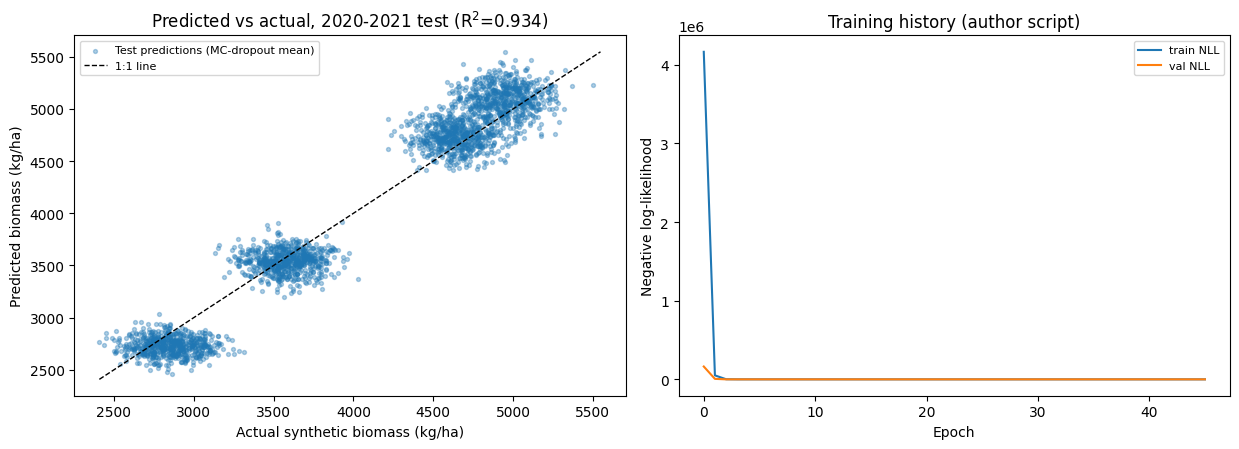

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

preds = test_results["predictions"].ravel()
targs = test_results["targets"].ravel()
lims = [float(min(targs.min(), preds.min())), float(max(targs.max(), preds.max()))]
axes[0].scatter(targs, preds, s=8, alpha=0.35, label="Test predictions (MC-dropout mean)")
axes[0].plot(lims, lims, "k--", lw=1, label="1:1 line")
axes[0].set_xlabel("Actual synthetic biomass (kg/ha)")
axes[0].set_ylabel("Predicted biomass (kg/ha)")
axes[0].set_title(f"Predicted vs actual, 2020-2021 test (R$^2$={test_results['r2']:.3f})")
axes[0].legend(fontsize=8)

axes[1].plot(history["train_loss"], label="train NLL")
axes[1].plot(history["val_loss"], label="val NLL")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Negative log-likelihood")
axes[1].set_title("Training history (author script)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("/content/mauqnet_results.png", dpi=120)
plt.show()


### 11. Summary table & CSV export — 結果表と CSV 出力

Collects the metrics from this run into a small table with units and writes
`/content/mauqnet_summary.csv` inside the Colab VM. Values are from the actual executed run.
本実行の指標を単位付きで表にまとめ、CSV として保存します。

In [ ]:
summary_df = pd.DataFrame(
    [
        ("R^2 (test)", f"{test_results['r2']:.4f}", "dimensionless"),
        ("RMSE (test)", f"{test_results['rmse']:.2f}", "kg/ha"),
        ("95% interval coverage", f"{test_results['coverage']:.1f}", "%"),
        ("Epistemic variance share", f"{test_results['epistemic_pct']:.1f}", "%"),
        ("Aleatoric variance share", f"{test_results['aleatoric_pct']:.1f}", "%"),
        ("Epochs run", str(len(history["train_loss"])), "count"),
    ],
    columns=["Metric", "Value", "Unit"],
)
summary_df.to_csv("/content/mauqnet_summary.csv", index=False)
summary_df


,Metric,Value,Unit
0,R^2 (test),0.9343,dimensionless
1,RMSE (test),217.86,kg/ha
2,95% interval coverage,100.0,%
3,Epistemic variance share,59.7,%
4,Aleatoric variance share,40.3,%
5,Epochs run,46,count


## Interpretation & limitations — 解釈と限界

- **What this run shows:** the authors' own example pipeline trains and produces its
  documented outputs (R², RMSE, 95 % coverage, epistemic/aleatoric shares) on the embedded
  synthetic data. Exact values depend on the fixed seed and device; CPU/GPU may differ in
  low-order digits and, with MC dropout, slightly more.
- **What this run does NOT show:** the paper's published results. The abstract reports
  R² = 0.856 with 97.18 % coverage on a 1272-sample 2012–2022 field dataset with a
  chronological 2020–2021 test — that dataset and the published configuration are not
  publicly available, so those numbers are out of scope. The abstract-level decomposition
  (epistemic ≈ 53 %, aleatoric ≈ 47 %) likewise refers to the real data.
- **Provenance caveats:** the repository has no LICENSE file (usage terms unclear), no
  README, and no published weights; the link between this example script and the exact
  published architecture could not be verified against the (bot-blocked) full text. Full
  article text was not verified through the attempted routes (ScienceDirect challenge;
  Elsevier TDM requires a key) — treat method details as coming from the code and abstract
  only.
- **この実行で示すこと:** 著者サンプルの合成データでの学習・評価パイプラインが動作し、
  R²・RMSE・95%被覆率・不確実性内訳が得られます。値はシードとデバイスに依存します。
- **この実行で示さないこと:** 論文の実データ結果（R²=0.856、被覆率 97.18% など）。
  実データと公開設定は入手不可のため対象外です。リポジトリに LICENSE はなく、
  例スクリプトと本論文アーキテクチャの対応は全文未検証のため確定していません。

**References**
- Paper: https://doi.org/10.1016/j.aiia.2026.03.007 (AIIA 16(2):788–803, 2026)
- Author code: https://github.com/JinpC-tech/MA-UQNet @ `ebfabdae2c770444788db857b393470bf333506f`
- PhenoPaper investigation `p-907e1df7e3c1fa6fcd55ff01f69cfba9-20260930T143331Z-3726844`
  was used as prior research guidance; all scientific claims above come from the pinned code.